In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from bias_fairness.utils import timer,profile_data

# Fairlearn - Dataset
https://fairlearn.org/v0.12/quickstart.html

The dataset consists of clinical data from diabetic patients across 130 U.S. hospitals, spanning 1998–2008. It records hospital readmissions within 30 days after release, which is used as a proxy for patients needing additional care. The goal is to predict 30-day readmission using machine learning. This dataset has been used in prior research on racial disparities in healthcare allocation and was featured in a 2021 Fairlearn SciPy tutorial.

In [4]:
def prep_data(df: pd.DataFrame, 
              target_str: str, 
              protected_list: list[str], 
              feature_list: list[str]):
    """
    Prepare dataset for bias and fairness analysis.
    
    Parameters:
    - df: pd.DataFrame input dataset (already loaded)
    - target_str: (str) target column name
    - protected_list: (list[str]) protected attribute columns for fairness analysis
    - feature_list: (list[str]) feature columns to include in model
    
    Returns:
    - X: pd.DataFrame of selected features including protected attributes
    - X_ohe: pd.DataFrame of features one-hot encoded (excluding protected attributes)
    - y: pd.Series target variable
    """
    if not protected_list:
        raise ValueError("protected_list must not be empty.")
    if not feature_list:
        raise ValueError("feature_list must not be empty.")
    if target_str not in df.columns:
        raise ValueError(f"Target column '{target_str}' not found in dataframe.")

    # Define columns to keep in X
    cols_to_keep = list(set(feature_list + protected_list))
    
    # Filter DataFrame
    df_filtered = df[cols_to_keep + [target_str]]
    
    # Separate target
    y = df_filtered[target_str]
    
    # Separate features
    X = df_filtered.drop(columns=[target_str])
    
    # One-hot encode
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    # categorical_cols = [col for col in categorical_cols if col not in protected_list]
    
    X_ohe = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

    X_protected = X.loc[:,protected_list]
    
    return X, X_ohe, y,X_protected

In [5]:
from fairlearn.datasets import fetch_diabetes_hospital

# Load data
data = fetch_diabetes_hospital(as_frame=True)
dh_df = data.data.copy()
dh_df.columns = dh_df.columns.str.lower()
dh_df['readmit_30_days'] = data.target
print(dh_df.columns)
# dh_df.to_csv('diabetes_hospital.csv',index=False)

drop_cols = ["readmitted", "readmit_binary",'readmit_30_days']
feature_cols = [col for col in dh_df.columns if col not in drop_cols]

# Run preparation
X, X_ohe, y, X_protected = prep_data(df=dh_df, 
                                       target_str="readmit_30_days",
                                       protected_list=["race"], # ,"gender"
                                       feature_list= feature_cols)

Index(['race', 'gender', 'age', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'primary_diagnosis', 'number_diagnoses', 'max_glu_serum', 'a1cresult',
       'insulin', 'change', 'diabetesmed', 'medicare', 'medicaid',
       'had_emergency', 'had_inpatient_days', 'had_outpatient_days',
       'readmitted', 'readmit_binary', 'readmit_30_days'],
      dtype='object')


In [6]:
X.columns

Index(['medicaid', 'had_inpatient_days', 'change', 'num_medications',
       'primary_diagnosis', 'number_diagnoses', 'age', 'medicare', 'gender',
       'max_glu_serum', 'num_procedures', 'had_emergency',
       'admission_source_id', 'diabetesmed', 'medical_specialty', 'a1cresult',
       'discharge_disposition_id', 'race', 'insulin', 'time_in_hospital',
       'had_outpatient_days', 'num_lab_procedures'],
      dtype='object')

In [7]:
X_ohe.columns

Index(['num_medications', 'number_diagnoses', 'num_procedures',
       'time_in_hospital', 'num_lab_procedures', 'medicaid_False',
       'medicaid_True', 'had_inpatient_days_False', 'had_inpatient_days_True',
       'change_Ch', 'change_No', 'primary_diagnosis_'Genitourinary Issues'',
       'primary_diagnosis_'Musculoskeletal Issues'',
       'primary_diagnosis_'Respiratory Issues'', 'primary_diagnosis_Diabetes',
       'primary_diagnosis_Other', 'age_'30 years or younger'',
       'age_'30-60 years'', 'age_'Over 60 years'', 'medicare_False',
       'medicare_True', 'gender_Female', 'gender_Male',
       'gender_Unknown/Invalid', 'max_glu_serum_>200', 'max_glu_serum_>300',
       'max_glu_serum_None', 'max_glu_serum_Norm', 'had_emergency_False',
       'had_emergency_True', 'admission_source_id_Emergency',
       'admission_source_id_Other', 'admission_source_id_Referral',
       'diabetesmed_No', 'diabetesmed_Yes', 'medical_specialty_Cardiology',
       'medical_specialty_Emergency/

In [8]:
X

,medicaid,had_inpatient_days,change,num_medications,primary_diagnosis,number_diagnoses,age,medicare,gender,max_glu_serum,...,admission_source_id,diabetesmed,medical_specialty,a1cresult,discharge_disposition_id,race,insulin,time_in_hospital,had_outpatient_days,num_lab_procedures
0,False,False,No,1,Diabetes,1,'30 years or younger',False,Female,None,...,Referral,No,Other,None,Other,Caucasian,No,1,False,41
1,False,False,Ch,18,Other,9,'30 years or younger',False,Female,None,...,Emergency,Yes,Missing,None,'Discharged to Home',Caucasian,Up,3,False,59
2,False,True,No,13,Other,6,'30 years or younger',False,Female,None,...,Emergency,Yes,Missing,None,'Discharged to Home',AfricanAmerican,No,2,True,11
3,False,False,Ch,16,Other,7,'30-60 years',False,Male,None,...,Emergency,Yes,Missing,None,'Discharged to Home',Caucasian,Up,2,False,44
4,False,False,Ch,8,Other,5,'30-60 years',False,Male,None,...,Emergency,Yes,Missing,None,'Discharged to Home',Caucasian,Steady,1,False,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,False,False,Ch,16,Diabetes,9,'Over 60 years',True,Male,None,...,Emergency,Yes,Missing,>8,Other,AfricanAmerican,Down,3,False,51
101762,False,True,No,18,Other,9,'Over 60 years',True,Female,None,...,Other,Yes,Missing,None,Other,AfricanAmerican,Steady,5,False,33
101763,False,False,Ch,9,Other,13,'Over 60 years',True,Male,None,...,Emergency,Yes,Missing,None,'Discharged to Home',Caucasian,Down,1,True,53
101764,False,True,Ch,21,Other,9,'Over 60 years',True,Female,None,...,Emergency,Yes,Other,None,Other,Caucasian,Up,10,False,45


In [9]:
X_ohe

,num_medications,number_diagnoses,num_procedures,time_in_hospital,num_lab_procedures,medicaid_False,medicaid_True,had_inpatient_days_False,had_inpatient_days_True,change_Ch,...,race_Caucasian,race_Hispanic,race_Other,race_Unknown,insulin_Down,insulin_No,insulin_Steady,insulin_Up,had_outpatient_days_False,had_outpatient_days_True
0,1,1,0,1,41,True,False,True,False,False,...,True,False,False,False,False,True,False,False,True,False
1,18,9,0,3,59,True,False,True,False,True,...,True,False,False,False,False,False,False,True,True,False
2,13,6,5,2,11,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
3,16,7,1,2,44,True,False,True,False,True,...,True,False,False,False,False,False,False,True,True,False
4,8,5,0,1,51,True,False,True,False,True,...,True,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,16,9,0,3,51,True,False,True,False,True,...,False,False,False,False,True,False,False,False,True,False
101762,18,9,3,5,33,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
101763,9,13,0,1,53,True,False,True,False,True,...,True,False,False,False,True,False,False,False,False,True
101764,21,9,2,10,45,True,False,False,True,True,...,True,False,False,False,False,False,False,True,True,False


In [10]:
y

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmit_30_days, Length: 101766, dtype: int64

In [11]:
X_protected

,race
0,Caucasian
1,Caucasian
2,AfricanAmerican
3,Caucasian
4,Caucasian
...,...
101761,AfricanAmerican
101762,AfricanAmerican
101763,Caucasian
101764,Caucasian


In [12]:
X_protected['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [13]:
profile_data(dh_df)

function: profile_data is starting...
function: profile_data successfully executed at 0.3271808624267578s


,features,dtype,missing,missing%,nunique,sample
0,race,object,0,0.0,6,"[Caucasian, AfricanAmerican, Unknown, Other, A..."
1,gender,object,0,0.0,3,"[Female, Male, Unknown/Invalid]"
2,age,object,0,0.0,3,"['30 years or younger', '30-60 years', 'Over 6..."
3,discharge_disposition_id,object,0,0.0,2,"[Other, 'Discharged to Home']"
4,admission_source_id,object,0,0.0,3,"[Referral, Emergency, Other]"
5,time_in_hospital,int64,0,0.0,14,"[1, 3, 2, 4, 5]"
6,medical_specialty,object,0,0.0,6,"[Other, Missing, InternalMedicine, Family/Gene..."
7,num_lab_procedures,int64,0,0.0,118,"[41, 59, 11, 44, 51]"
8,num_procedures,int64,0,0.0,7,"[0, 5, 1, 6, 2]"
9,num_medications,int64,0,0.0,75,"[1, 18, 13, 16, 8]"


# Count & Prevalence
"Prevalence" หรือ ความชุก เช่น สัดส่วนของผู้ที่เป็นโรคใดโรคหนึ่งในประชากรกลุ่มหนึ่ง ณ ช่วงเวลาใดเวลาหนึ่ง กล่าวอีกนัยหนึ่งคือ เป็นการนับจำนวนผู้ป่วยทั้งหมด (ทั้งผู้ป่วยรายใหม่และผู้ป่วยเดิม) ที่เป็นโรคในช่วงเวลาที่ทำการศึกษา แล้วหารด้วยจำนวนประชากรทั้งหมดในช่วงเวลานั้น 

## Count

In [14]:
def plot_protected_counts(X: pd.DataFrame, 
                          y: pd.Series, 
                          protected_list: list[str]):
    """
    Plot count distribution for each protected attribute in the list.

    Parameters:
    - X: pd.DataFrame - features (must include protected attributes)
    - y: pd.Series - target variable (not used, but passed for future extension)
    - protected_list: list[str] - list of protected attribute column names
    """
    for protected_col in protected_list:
        if protected_col not in X.columns:
            print(f"[Warning] Column '{protected_col}' not found in X. Skipping.")
            continue

        # Count values
        df_counts = X[protected_col].value_counts().reset_index()
        df_counts.columns = [protected_col, "count"]

        # Plot
        fig, ax = plt.subplots()
        ax.bar(df_counts[protected_col], df_counts["count"])
        ax.set_title(f"Counts by {protected_col}")
        ax.set_xlabel(protected_col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", labelrotation=45)

        plt.tight_layout()
        plt.show()


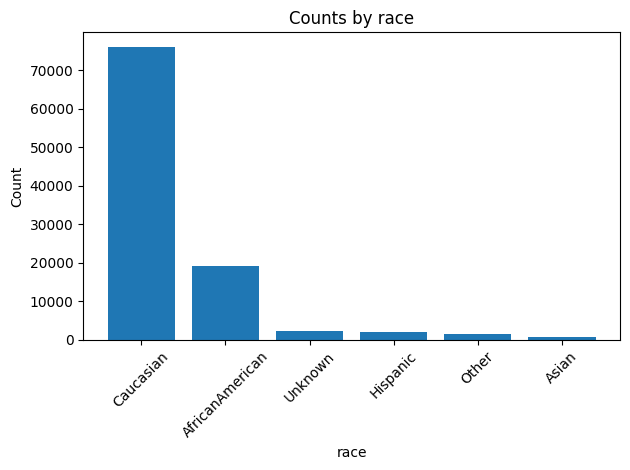

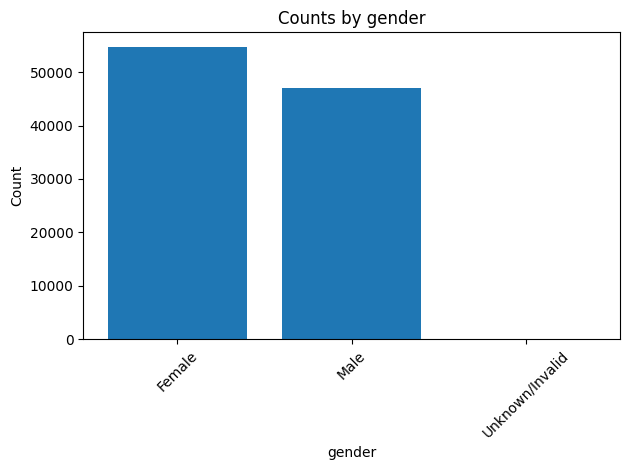

In [15]:
plot_protected_counts(X = X, 
                      y = y, 
                      protected_list = ['race','gender']
                     )

In [16]:
dh_df['readmit_30_days'].value_counts(dropna=False)

readmit_30_days
0    90409
1    11357
Name: count, dtype: int64

## Prevalence

In [17]:
@timer
def plot_prevalence_by_group(X: pd.DataFrame, 
                              y: pd.Series, 
                              protected_list: list[str]) -> dict:
    """
    Plot total count (bar, left axis) and prevalence % (line, right axis) 
    for each group in protected attributes.

    Parameters:
    - X: pd.DataFrame - includes protected attributes
    - y: pd.Series - binary target variable
    - protected_list: list[str] - names of protected attribute columns

    Returns:
    - result_dict: dict[str, pd.DataFrame] with prevalence and count breakdowns
    """
    result_dict = {}

    for protected_col in protected_list:
        if protected_col not in X.columns:
            print(f"[Warning] Column '{protected_col}' not found in X. Skipping.")
            continue

        # Combine and group
        df_temp = pd.concat([X[protected_col], y], axis=1)
        numerator = df_temp[df_temp[y.name] == 1].groupby(protected_col).size()
        denominator = df_temp.groupby(protected_col).size()
        prevalence_pct = (numerator / denominator * 100).fillna(0)

        # Create debug DataFrame
        debug_df = pd.DataFrame({
            "y=1_count": numerator,
            "total_count": denominator,
            "prevalence_%": prevalence_pct
        }).fillna(0).sort_values("total_count", ascending=False)

        print(f"\nPrevalence breakdown for: {protected_col}")
        print(debug_df)

        # Prepare for plotting
        grouped = debug_df.reset_index()
        result_dict[protected_col] = grouped

        # Plot: dual axis
        fig, ax1 = plt.subplots(figsize=(7, 4))

        # Bar plot for total count (left y-axis)
        bars = ax1.bar(grouped[protected_col], grouped["total_count"], color='steelblue', label="Total Count")
        ax1.set_ylabel("Total Count", color='steelblue')
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.set_xlabel(protected_col)
        ax1.tick_params(axis="x", labelrotation=45)

        # Line plot for prevalence (right y-axis)
        ax2 = ax1.twinx()
        ax2.plot(grouped[protected_col], grouped["prevalence_%"], color='darkred', marker='o', label="Prevalence (%)")
        ax2.set_ylabel("Prevalence (%)", color='darkred')
        ax2.tick_params(axis='y', labelcolor='darkred')

        # # Annotate bars with count
        # for bar, count in zip(bars, grouped["total_count"]):
        #     height = bar.get_height()
        #     ax1.annotate(f'{int(count)}', xy=(bar.get_x() + bar.get_width() / 2, height),
        #                  xytext=(0, 3), textcoords="offset points",
        #                  ha='center', va='bottom', fontsize=9, color = 'steelblue')
            
        # Annotate line points with prevalence %
        for x, y_val in zip(grouped[protected_col], grouped["prevalence_%"]):
            ax2.annotate(f'{y_val:.1f}%', xy=(x, y_val),
                         xytext=(0, 5), textcoords="offset points",
                         ha='center', va='bottom', fontsize=9, color='darkred')

        # Title and legend
        ax1.set_title(f"Total Count and Prevalence by {protected_col}")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

        plt.tight_layout()
        plt.show()

    return result_dict

function: plot_prevalence_by_group is starting...

Prevalence breakdown for: race
                 y=1_count  total_count  prevalence_%
race                                                 
Caucasian             8592        76099     11.290556
AfricanAmerican       2155        19210     11.218116
Unknown                188         2273      8.271007
Hispanic               212         2037     10.407462
Other                  145         1506      9.628154
Asian                   65          641     10.140406


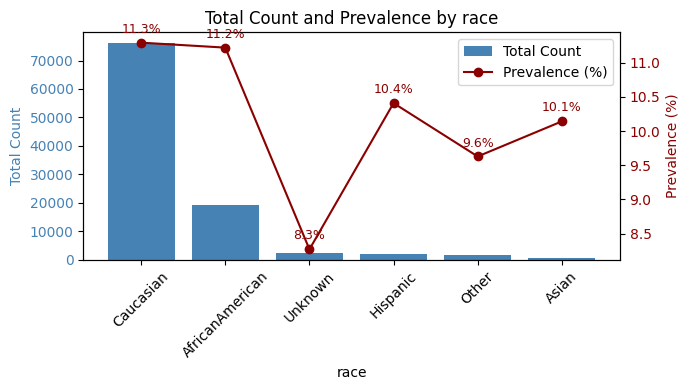


Prevalence breakdown for: gender
                 y=1_count  total_count  prevalence_%
gender                                               
Female              6152.0        54708     11.245156
Male                5205.0        47055     11.061524
Unknown/Invalid        0.0            3      0.000000


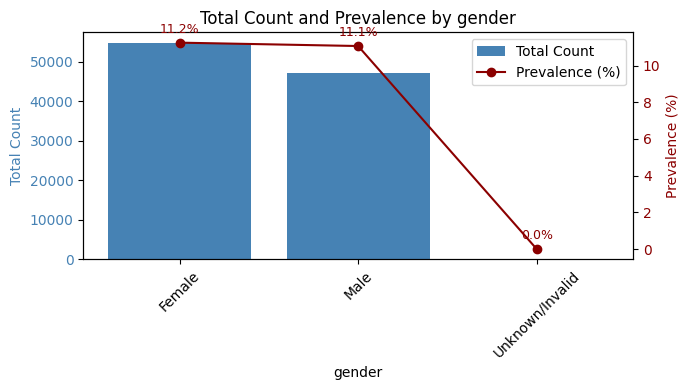

function: plot_prevalence_by_group successfully executed at 0.5600087642669678s


{'race':               race  y=1_count  total_count  prevalence_%
 0        Caucasian       8592        76099     11.290556
 1  AfricanAmerican       2155        19210     11.218116
 2          Unknown        188         2273      8.271007
 3         Hispanic        212         2037     10.407462
 4            Other        145         1506      9.628154
 5            Asian         65          641     10.140406,
 'gender':             gender  y=1_count  total_count  prevalence_%
 0           Female     6152.0        54708     11.245156
 1             Male     5205.0        47055     11.061524
 2  Unknown/Invalid        0.0            3      0.000000}

In [18]:
plot_prevalence_by_group(X = X, 
                          y = y, 
                          protected_list = ['race','gender']
                         )
# y = 1 means the patient was readmitted within 30 days.
# Higher prevalence = more people in that group were readmitted → worse health outcome.

We must identify sensitive class.
According to fairlearn example, i will choose African American race as sensitive class.

**The protected attribute refers to the whole column (e.g., race, gender), while a sensitive class is one specific value of that attribute (e.g., race = AfricanAmerican, gender = Female).**

# Evaluating fairness-related metrics

## Define models in order to get y_pred/predict_proba across groups defined by protected attributes
- goal : to test how the model behaves across different groups.
- example : A classifier may achieve 90% accuracy overall, but only 70% for one group (e.g., "AfricanAmerican") and 95% for another (e.g., "Caucasian"). This disparity signals bias or fairness issues even if the model looks good on average.

| Step                                       | Purpose                         |
| ------------------------------------------ | ------------------------------- |
| 1. Model trains on features `X`            | Learns decision rules from data |
| 2. Model predicts `y_pred` on test set     | Applies learned logic           |
| 3. Compare `y_pred` to `y_true`            | Measures correctness            |
| 4. Compare metrics by group (e.g., `race`) | Measures **fairness**           |


In [19]:
# Logistic Regression - A linear model that estimates probabilities using a logistic function.
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)

# Random Forest - An ensemble of decision trees that improves accuracy and robustness via bagging.
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

# Gradient Boosting - Builds trees sequentially, each correcting errors from the previous ones.
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier(random_state=42)

# HistGradientBoosting - Optimized gradient boosting using histogram-based splits, good for large datasets.
from sklearn.ensemble import HistGradientBoostingClassifier
model_hgb = HistGradientBoostingClassifier(random_state=42)

# Extra Trees - Like Random Forest but splits are chosen randomly, often faster and more diverse.
from sklearn.ensemble import ExtraTreesClassifier
model_et = ExtraTreesClassifier(random_state=42)

# Gaussian Naive Bayes - A probabilistic model assuming features follow Gaussian distribution and are independent.
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()

# K-Nearest Neighbors - Assigns class based on the majority of the k-nearest data points in the training set.
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5)

# Multi-Layer Perceptron - A feedforward neural network trained via backpropagation.
from sklearn.neural_network import MLPClassifier
model_nn = MLPClassifier(hidden_layer_sizes=(13,), max_iter=500)

# Support Vector Classifier - Maximizes margin between classes; with `probability=True` it estimates class probabilities via Platt scaling.
from sklearn.svm import SVC
model_svc = SVC(probability=True)

In [20]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from fairlearn.metrics import MetricFrame
from sklearn.metrics import (
                            accuracy_score,
                            balanced_accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score,
                            roc_auc_score,
                            average_precision_score,
                            log_loss,
                            )
from fairlearn.metrics import (
                            MetricFrame,
                            false_positive_rate,
                            false_negative_rate,
                            selection_rate,
                            true_positive_rate,
                            true_negative_rate,
                            demographic_parity_difference,
                            selection_rate,
                            count
                        )

def zero_div_precision_score(y_true, y_pred):
    '''
    This parameter tells precision_score to return 0 instead of raising an error 
    when there are no positive predictions.
    '''
    return precision_score(y_true, y_pred, zero_division=0)

@timer
def evaluate_fairness_metrics(
    X_ohe: pd.DataFrame,
    y: pd.Series,
    X_protected: pd.DataFrame,
    model: BaseEstimator = None,
    metrics: dict = None,
    threshold: float = 0.5,
    test_size: float = 0.3,
    random_state: int = 42,
    return_frame: bool = True,
):
    """
    Evaluate multiple fairness metrics across protected attributes using Fairlearn.

    Parameters:
    - X_ohe (pd.DataFrame): Feature matrix (may include protected columns).
    - y (pd.Series): Binary target.
    - X_protected (pd.DataFrame): Protected attributes (multiple columns allowed).
    - model (BaseEstimator): Any sklearn classifier. If None, uses DecisionTreeClassifier.
    - metrics (dict): Dictionary of metric name: function pairs.
    - threshold (float): Threshold for binarizing predict_proba output.
    - test_size (float): Fraction of data used for test set.
    - random_state (int): Random seed.
    - return_frame (bool): Whether to return MetricFrame object(s).

    Returns:
    - Dict of metric results per protected attribute. Each entry includes:
      - overall: dict of overall scores
      - by_group: DataFrame of scores per group
      - (optional) metric_frame: Fairlearn MetricFrame object
    """
    if model is None:
        model = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4, random_state=random_state)

    if metrics is None:
        metrics = {
            "accuracy": accuracy_score,  # % of correct predictions in the group
            "precision": zero_div_precision_score,  # % of predicted positives that are actually positive
            "recall": recall_score,  # % of actual positives that are correctly predicted (true positive rate)
            "false positive rate": false_positive_rate,  # % of actual negatives misclassified as positive (Type I error rate)
            "false negative rate": false_negative_rate,  # % of actual positives misclassified as negative (Type II error rate)
            "true positive rate" : true_positive_rate,  # % of actual positives correctly classified as positive (sensitivity or recall)
            "true negative rate" : true_negative_rate, # % of actual negatives correctly classified as negative (specificity)
            "selection rate": selection_rate,  # % predicted as positive regardless of ground truth (positive outcome rate)  
            "count": count, # Number of individuals in the group
        
        }

    results = {}

    for protected_col in X_protected.columns:
        A = X_protected[protected_col]

        X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
            X_ohe, y, A, test_size=test_size, random_state=random_state
        )

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_pred = (model.predict_proba(X_test)[:, 1] >= threshold).astype(int)
        else:
            y_pred = model.predict(X_test)

        mf = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

        results[protected_col] = {
            "overall": mf.overall.to_dict(),
            "by_group": mf.by_group,
            "y_true": y_test.reset_index(drop=True),
            "y_pred": pd.Series(y_pred).reset_index(drop=True),
            "protected": A_test.reset_index(drop=True)
        }

        if return_frame:
            results[protected_col]["metric_frame"] = mf

    return results

In [21]:
eval_before = evaluate_fairness_metrics(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # ใส่ cat เข้าไป (แบบไม่ one-hot)
    model = model_lr,
    metrics=None,
    threshold = 0.1,
)

function: evaluate_fairness_metrics is starting...
function: evaluate_fairness_metrics successfully executed at 2.74409556388855s


In [22]:
eval_before

{'race': {'overall': {'accuracy': 0.5529642974123813,
   'precision': 0.1550246338665047,
   'recall': 0.6706569343065694,
   'false positive rate': 0.4619073971591957,
   'false negative rate': 0.32934306569343064,
   'true positive rate': 0.6706569343065694,
   'true negative rate': 0.5380926028408043,
   'selection rate': 0.48532590894202426,
   'count': 30530.0},
  'by_group':                  accuracy  precision    recall  false positive rate  \
  race                                                                  
  AfricanAmerican  0.541060   0.152099  0.704944             0.478912   
  Asian            0.604396   0.120000  0.600000             0.395210   
  Caucasian        0.545137   0.155165  0.672797             0.471287   
  Hispanic         0.647059   0.196581  0.741935             0.364341   
  Other            0.692308   0.181102  0.450980             0.275132   
  Unknown          0.738095   0.132911  0.350000             0.223856   
  
                   false negati

In [23]:
eval_before['race']['y_pred'].value_counts()

0    15713
1    14817
Name: count, dtype: int64

In [24]:
eval_before['race']['overall']

{'accuracy': 0.5529642974123813,
 'precision': 0.1550246338665047,
 'recall': 0.6706569343065694,
 'false positive rate': 0.4619073971591957,
 'false negative rate': 0.32934306569343064,
 'true positive rate': 0.6706569343065694,
 'true negative rate': 0.5380926028408043,
 'selection rate': 0.48532590894202426,
 'count': 30530.0}

In [25]:
eval_before['race']['by_group']

,accuracy,precision,recall,false positive rate,false negative rate,true positive rate,true negative rate,selection rate,count
race,,,,,,,,,
AfricanAmerican,0.541060,0.152099,0.704944,0.478912,0.295056,0.704944,0.521088,0.503465,5772.0
Asian,0.604396,0.120000,0.600000,0.395210,0.400000,0.600000,0.604790,0.412088,182.0
Caucasian,0.545137,0.155165,0.672797,0.471287,0.327203,0.672797,0.528713,0.494257,22897.0
Hispanic,0.647059,0.196581,0.741935,0.364341,0.258065,0.741935,0.635659,0.404844,578.0
Other,0.692308,0.181102,0.450980,0.275132,0.549020,0.450980,0.724868,0.296037,429.0
Unknown,0.738095,0.132911,0.350000,0.223856,0.650000,0.350000,0.776144,0.235119,672.0


In [26]:
def plot_metric_frame(metric_frame, title="Fairness Metrics by Group"):
    metric_frame.by_group.plot.bar(
        subplots=True,
        layout=[3, 3],
        legend=False,
        figsize=[12, 8],
        title=title,
    )

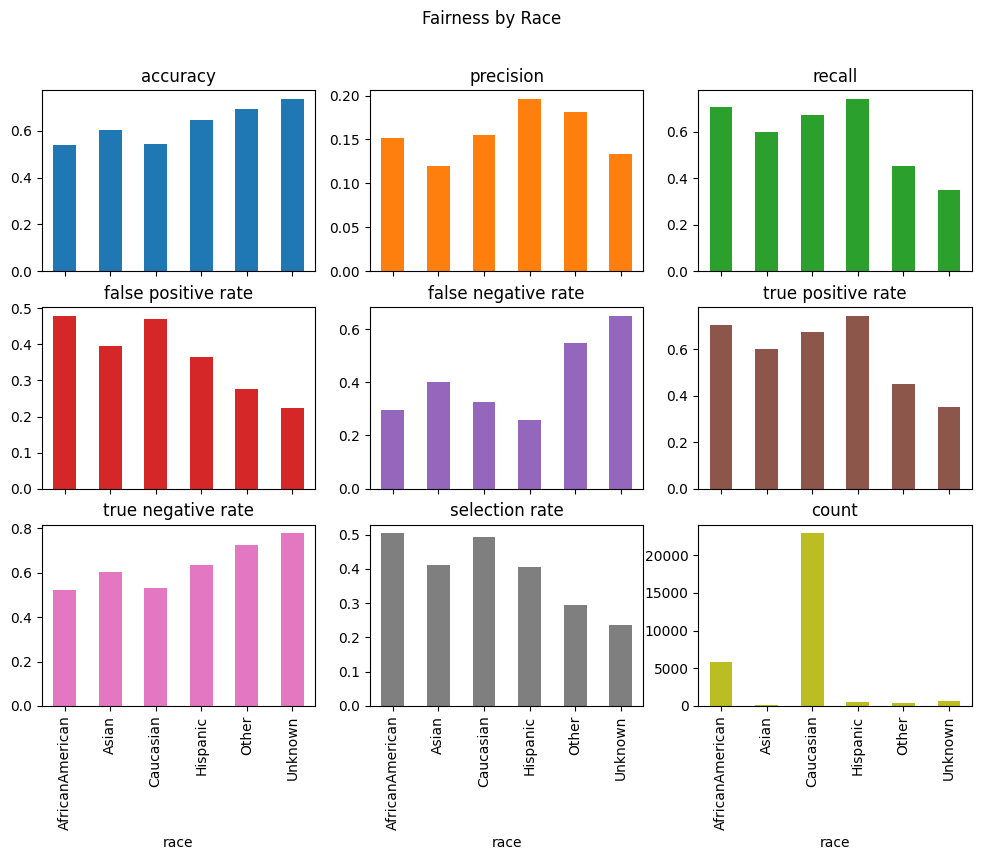

In [27]:
plot_metric_frame(eval_before["race"]["metric_frame"], title="Fairness by Race")

In [26]:
# ไม่รู้ทำไมรันไม่ได้
# equalized_odds_difference,
# average_odds_difference,
# error_rate
# zero_div_precision_score

# Mitigating disparity

- If a model shows **unfair treatment between groups**, we may need to retrain it with **fairness constraints**.
- The **choice of fairness constraint** depends on the real-world situation and what's most important (e.g., reducing certain types of errors).
- In cases where both **false positives** and **false negatives** matter, we can use the **Equalized Odds** constraint:
  - This ensures that **error rates are balanced across all groups**.
- To enforce this, we can apply the **Exponentiated Gradient** technique:
  - It trains a model that follows Equalized Odds while minimizing overall error.
- This method often leads to **smaller gaps in accuracy** between groups.

ไม่มีการใช้ threshold แล้ว เพราะไม่มีการตัด proba
- ExponentiatedGradient and other Fairlearn reduction algorithms (like GridSearch) do not use predict_proba() + thresholding like traditional classifiers.
- Instead:
They produce a classifier ensemble and optimize predictions internally under fairness constraints.

"exponentiated gradient reduction"
https://fairlearn.org/v0.12/api_reference/generated/fairlearn.reductions.ExponentiatedGradient.html#fairlearn.reductions.ExponentiatedGradient
-  EG iteratively reweights data and retrains the same model, not by random seeds, but by optimizing a fairness-accuracy tradeoff.

https://fairlearn.org/v0.12/quickstart.html

In [28]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from fairlearn.reductions import ErrorRate, EqualizedOdds, ExponentiatedGradient
from fairlearn.metrics import MetricFrame
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
)
from fairlearn.metrics import (
    MetricFrame,
    false_positive_rate,
    false_negative_rate,
    selection_rate,
    true_positive_rate,
    true_negative_rate,
    demographic_parity_difference,
    selection_rate,
    count
)
# constraint
from fairlearn.reductions import (
    DemographicParity,             # Demographic Parity constraint
    EqualizedOdds,                 # Equalized Odds constraint
    TruePositiveRateParity,        # True Positive Rate Parity constraint
    FalsePositiveRateParity,       # False Positive Rate Parity constraint
    ErrorRateParity                # Error Rate Parity constraint
)
    
@timer
def mitigate_fairness_disparity(
    X_ohe: pd.DataFrame,
    y: pd.Series,
    X_protected: pd.DataFrame,
    model: BaseEstimator = None,
    constraint=None,
    objective=None,
    metrics: dict = None,
    test_size: float = 0.3,
    random_state: int = 42,
    return_frame: bool = True,
):
    """
    Mitigate disparity across protected attributes using Exponentiated Gradient method.

    Parameters:
    - X_ohe (pd.DataFrame): Feature matrix (may include protected columns).
    - y (pd.Series): Binary target.
    - X_protected (pd.DataFrame): Protected attributes (multiple columns allowed).
    - model (BaseEstimator): Base classifier. If None, uses DecisionTreeClassifier.
    - constraint (Moment object): Fairness constraint to enforce. 
        Must be an **instance** of a subclass of `ClassificationMoment`.
        Available constraint options:
        | Constraint               | Fairness Goal                                | Related Metrics                        |
        |--------------------------|-----------------------------------------------|----------------------------------------|
        | DemographicParity        | Equal selection rates across groups           | `selection rate`                       |
        | TruePositiveRateParity   | Equal opportunity: TPR parity across groups   | `recall`, `true positive rate`         |
        | FalsePositiveRateParity  | Equal false alarm rate                        | `false positive rate`                  |
        | EqualizedOdds [Default]  | Equal TPR and FPR across groups               | `recall`, `FPR`, `TPR`                 |
        | ErrorRateParity          | Equal misclassification rate across groups    | `accuracy`, `error rate`, `count`      |
        
   - objective (LossMoment object): Custom loss function to minimize.
        Must be an **instance** of a subclass of `LossMoment` (e.g., `ErrorRate`).
        You can assign misclassification costs (weight) to tune behavior:
            - ErrorRate(costs={"fp": 0.1, "fn": 0.9}) → favor recall
                The model is penalized more heavily for False Negatives than for False Positives.
                This setup encourages the model to reduce false negatives, even if it causes more false positives.           
            - ErrorRate(costs={"fp": 0.9, "fn": 0.1}) → favor precision
                The model is penalized more heavily for False Positives than for False Negatives.
                This setup encourages the model to reduce false positives, even if it causes more false negatives.

        | Bias Preference      | Cost Setting     | Metric Affected        | Use Case                                            |
        +----------------------+------------------+------------------------+-----------------------------------------------------+
        | Favor Recall         | {"fp": 0.1,       | ↑ Recall, ↓ Precision  | Medical diagnosis, fraud detection                  |
        |                      |  "fn": 0.9}       |                        | (catch more positives even if more false alarms)    |
        +----------------------+------------------+------------------------+-----------------------------------------------------+
        | Favor Precision      | {"fp": 0.9,       | ↑ Precision, ↓ Recall  | Spam filter, loan approval                          |
        |                      |  "fn": 0.1}       |                        | (be more conservative in predicting positives)      |
            
    - metrics (dict): Dictionary of metric name: function pairs. Use metrics relevant to the fairness constraint you apply.
        Include any of:
            - accuracy
            - precision
            - recall
            - false positive rate
            - false negative rate
            - true negative rate
            - true positive rate
            - selection rate
            - count

    - test_size (float): Fraction of data used for test set.
    - random_state (int): Random seed.
    - return_frame (bool): Whether to return MetricFrame object(s).

    Returns:
    - Dict of metric results per protected attribute. Each includes:
        - 'overall': dict of overall scores
        - 'by_group': DataFrame of group-wise scores
        - (optional) 'metric_frame': full MetricFrame

    Notes:
    - ExponentiatedGradient does NOT support `predict_proba` or threshold tuning.
    - Custom cost via `ErrorRate(costs={"fp":..., "fn":...})` acts like threshold control.
    """
    if model is None:
        model = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4, random_state=random_state)

    if constraint is None:
        constraint = EqualizedOdds(difference_bound=0.01)

    if objective is None:
        objective = ErrorRate(costs={"fp": 0.1, "fn": 0.9}) # favor recall ไม่อยากให้พลาดคนที่+
        
    if metrics is None:
        metrics = {
            "accuracy": accuracy_score,
            "precision": zero_div_precision_score,
            "recall": recall_score,
            "false positive rate": false_positive_rate,
            "false negative rate": false_negative_rate,
            "true positive rate": true_positive_rate,
            "true negative rate": true_negative_rate,
            "selection rate": selection_rate,
            "count": count,
        }

    results = {}

    # Run mitigation for each protected attribute separately
    for protected_col in X_protected.columns:
        A = X_protected[protected_col]

        # Split data
        X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
            X_ohe, y, A, test_size=test_size, random_state=random_state
        )

        # Apply fairness mitigation
        mitigator = ExponentiatedGradient(model, constraints=constraint, objective=objective)
        mitigator.fit(X_train, y_train, sensitive_features=A_train)
        y_pred = mitigator.predict(X_test)

        # Calculate fairness metrics
        mf = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

        results[protected_col] = {
            "overall": mf.overall.to_dict(),
            "by_group": mf.by_group,
            "y_true": y_test.reset_index(drop=True),
            "y_pred": pd.Series(y_pred).reset_index(drop=True),
            "protected": A_test.reset_index(drop=True)
        }

        if return_frame:
            results[protected_col]["metric_frame"] = mf

    return results

In [29]:
eval_after = mitigate_fairness_disparity(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # e.g., df[['race', 'gender']]
    model = model_rf,
    constraint=None,
    objective=None,
    metrics = None,
    test_size= 0.3,
)

function: mitigate_fairness_disparity is starting...
function: mitigate_fairness_disparity successfully executed at 177.79208040237427s


In [30]:
eval_after

{'race': {'overall': {'accuracy': 0.5182115951523092,
   'precision': 0.15134099616858238,
   'recall': 0.7150364963503649,
   'false positive rate': 0.506659287954252,
   'false negative rate': 0.284963503649635,
   'true positive rate': 0.7150364963503649,
   'true negative rate': 0.49334071204574803,
   'selection rate': 0.5300360301342941,
   'count': 30530.0},
  'by_group':                  accuracy  precision    recall  false positive rate  \
  race                                                                  
  AfricanAmerican  0.528413   0.154860  0.749601             0.498542   
  Asian            0.489011   0.093750  0.600000             0.520958   
  Caucasian        0.516137   0.151739  0.706897             0.508404   
  Hispanic         0.550173   0.167785  0.806452             0.480620   
  Other            0.510490   0.158798  0.725490             0.518519   
  Unknown          0.486607   0.105263  0.633333             0.527778   
  
                   false negative

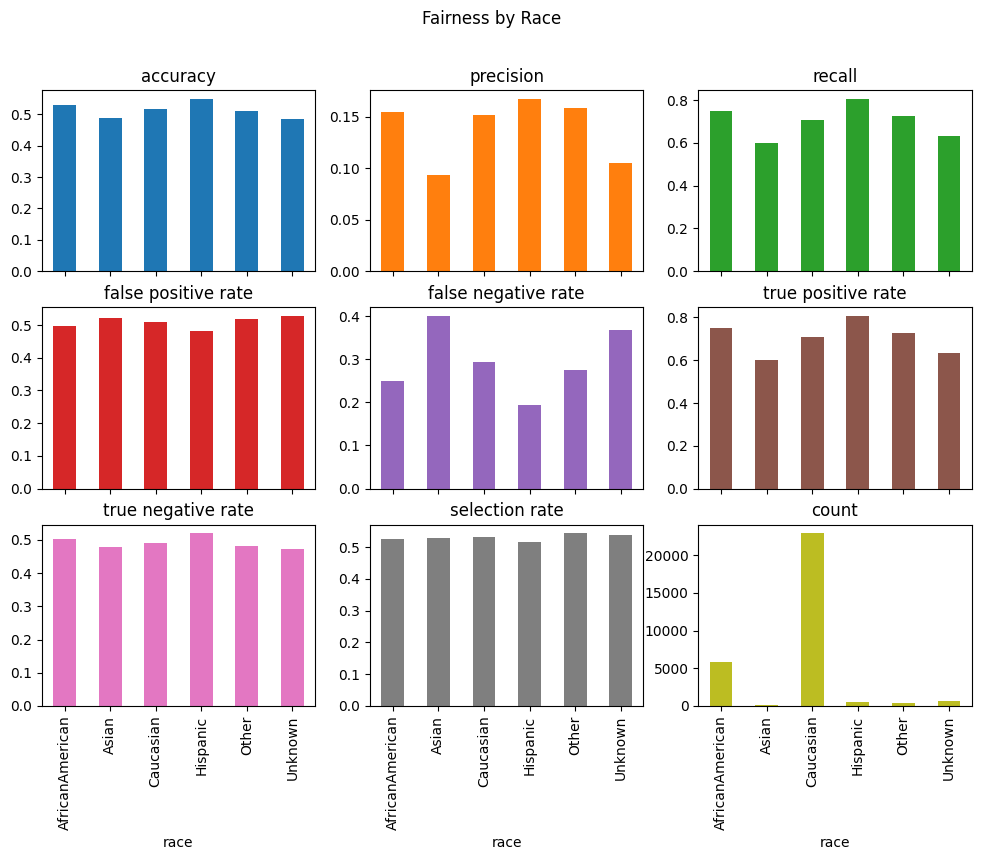

In [31]:
plot_metric_frame(eval_after["race"]["metric_frame"], title="Fairness by Race")

In [32]:
eval_before['race']['overall']

{'accuracy': 0.5529642974123813,
 'precision': 0.1550246338665047,
 'recall': 0.6706569343065694,
 'false positive rate': 0.4619073971591957,
 'false negative rate': 0.32934306569343064,
 'true positive rate': 0.6706569343065694,
 'true negative rate': 0.5380926028408043,
 'selection rate': 0.48532590894202426,
 'count': 30530.0}

In [33]:
eval_after['race']['overall']

{'accuracy': 0.5182115951523092,
 'precision': 0.15134099616858238,
 'recall': 0.7150364963503649,
 'false positive rate': 0.506659287954252,
 'false negative rate': 0.284963503649635,
 'true positive rate': 0.7150364963503649,
 'true negative rate': 0.49334071204574803,
 'selection rate': 0.5300360301342941,
 'count': 30530.0}

In [34]:
eval_before['race']['by_group']

,accuracy,precision,recall,false positive rate,false negative rate,true positive rate,true negative rate,selection rate,count
race,,,,,,,,,
AfricanAmerican,0.541060,0.152099,0.704944,0.478912,0.295056,0.704944,0.521088,0.503465,5772.0
Asian,0.604396,0.120000,0.600000,0.395210,0.400000,0.600000,0.604790,0.412088,182.0
Caucasian,0.545137,0.155165,0.672797,0.471287,0.327203,0.672797,0.528713,0.494257,22897.0
Hispanic,0.647059,0.196581,0.741935,0.364341,0.258065,0.741935,0.635659,0.404844,578.0
Other,0.692308,0.181102,0.450980,0.275132,0.549020,0.450980,0.724868,0.296037,429.0
Unknown,0.738095,0.132911,0.350000,0.223856,0.650000,0.350000,0.776144,0.235119,672.0


In [35]:
eval_after['race']['by_group']

,accuracy,precision,recall,false positive rate,false negative rate,true positive rate,true negative rate,selection rate,count
race,,,,,,,,,
AfricanAmerican,0.528413,0.154860,0.749601,0.498542,0.250399,0.749601,0.501458,0.525814,5772.0
Asian,0.489011,0.093750,0.600000,0.520958,0.400000,0.600000,0.479042,0.527473,182.0
Caucasian,0.516137,0.151739,0.706897,0.508404,0.293103,0.706897,0.491596,0.531030,22897.0
Hispanic,0.550173,0.167785,0.806452,0.480620,0.193548,0.806452,0.519380,0.515571,578.0
Other,0.510490,0.158798,0.725490,0.518519,0.274510,0.725490,0.481481,0.543124,429.0
Unknown,0.486607,0.105263,0.633333,0.527778,0.366667,0.633333,0.472222,0.537202,672.0


## Debug confusion matrix

In [36]:
import pandas as pd

def count_pred_true_by_group(results_dict, group_col='race'):
    """
    Count predicted and actual class (0/1) for each group in protected attribute.

    Parameters:
    - results_dict: dict
        Dictionary returned from mitigate_fairness_disparity (with 'y_pred', 'y_true', 'protected')
    - group_col: str
        Name of the protected attribute key in the dictionary (e.g., 'race')

    Returns:
    - pd.DataFrame: Combined counts of predicted and actual labels per group
    """
    df = pd.DataFrame({
        'group': results_dict[group_col]['protected'],
        'y_pred': results_dict[group_col]['y_pred'],
        'y_true': results_dict[group_col]['y_true']
    })

    # Count predicted values
    pred_counts = df.groupby('group')['y_pred'].value_counts().unstack(fill_value=0)
    pred_counts.columns = ['Predicted Negative (0)', 'Predicted Positive (1)']

    # Count actual values
    true_counts = df.groupby('group')['y_true'].value_counts().unstack(fill_value=0)
    true_counts.columns = ['Actual Negative (0)', 'Actual Positive (1)']

    # Merge
    combined = pd.concat([pred_counts, true_counts], axis=1)

    return combined


In [37]:
count_pred_true_by_group(eval_before, group_col='race')

,Predicted Negative (0),Predicted Positive (1),Actual Negative (0),Actual Positive (1)
group,,,,
AfricanAmerican,2866,2906,5145,627
Asian,107,75,167,15
Caucasian,11580,11317,20287,2610
Hispanic,344,234,516,62
Other,302,127,378,51
Unknown,514,158,612,60


In [38]:
count_pred_true_by_group(eval_after, group_col='race')

,Predicted Negative (0),Predicted Positive (1),Actual Negative (0),Actual Positive (1)
group,,,,
AfricanAmerican,2737,3035,5145,627
Asian,86,96,167,15
Caucasian,10738,12159,20287,2610
Hispanic,280,298,516,62
Other,196,233,378,51
Unknown,311,361,612,60


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_compare_pred_true_by_group(eval_before, eval_after, group_col='race', figsize=(14, 6)):
    df_before = count_pred_true_by_group(eval_before, group_col=group_col).add_prefix('Before_')
    df_after = count_pred_true_by_group(eval_after, group_col=group_col).add_prefix('After_')

    df_compare = df_before.join(df_after)
    df_compare.index.name = 'group'
    df_long = df_compare.reset_index().melt(id_vars='group', var_name='metric', value_name='count')

    # Extract Time (Before/After), Type (Predicted/Actual), and Class (Negative/Positive)
    df_long[['Time', 'Type', 'Class']] = df_long['metric'].str.extract(
        r'(Before|After)_(Predicted|Actual) (Negative|Positive) \(\d\)'
    )
    df_long.drop(columns='metric', inplace=True)

    # Actual only exists in Before or After, collapse them to one bar by taking 'Before' data (or mean)
    actual_df = df_long[df_long['Type'] == 'Actual'].copy()
    actual_df = actual_df.groupby(['group', 'Type', 'Class'], as_index=False)['count'].mean()
    actual_df['Time'] = 'Actual'  # Use custom Time label for plotting

    # Predicted Before/After separately
    predicted_df = df_long[df_long['Type'] == 'Predicted'].copy()

    # Combine for plotting
    plot_df = pd.concat([predicted_df, actual_df], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for i, cls in enumerate(['Negative', 'Positive']):
        ax = axes[i]
        sub = plot_df[plot_df['Class'] == cls]

        # Create combined hue label:
        # For predicted: "Predicted Before" or "Predicted After"
        # For actual: just "Actual"
        sub = sub.copy()
        sub['Hue'] = sub.apply(
            lambda r: f"{r['Type']} {r['Time']}" if r['Type'] == 'Predicted' else 'Actual', axis=1
        )

        sns.barplot(
            data=sub,
            x='group',
            y='count',
            hue='Hue',
            palette='Set1',
            edgecolor='black',
            ax=ax,
            dodge=True,
        )
        ax.set_title(f'{cls} Class')
        ax.set_xlabel('')
        if i == 0:
            ax.set_ylabel('Count')
        else:
            ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=45)
        if i == 1:
            ax.legend(title='Type & Time')
        else:
            ax.legend_.remove()

    plt.tight_layout()
    plt.show()

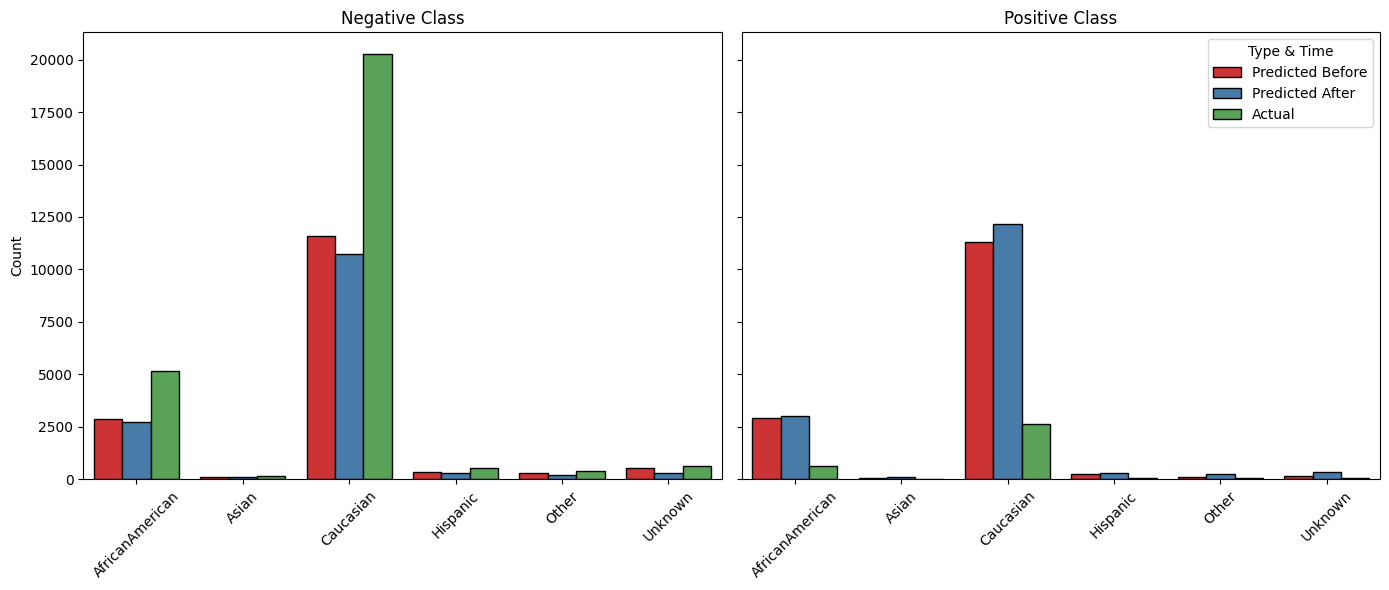

In [40]:
plot_compare_pred_true_by_group(eval_before, eval_after, group_col='race')

# Compare results

In [41]:
def compare_fairness_results_all_metrics(eval_before: dict, eval_after: dict, protected_attr: str):
    """
    Compare fairness metrics before and after mitigation in long format,
    including both group-level and overall metrics.

    Parameters:
    - eval_before (dict): Output from mitigate_fairness_disparity() before mitigation.
    - eval_after (dict): Output from mitigate_fairness_disparity() after mitigation.
    - protected_attr (str): Key of the protected attribute (e.g., "race", "gender").

    Returns:
    - pd.DataFrame
    """
    import pandas as pd

    # --------------------------
    # Group-level comparison
    # --------------------------
    df_before = eval_before[protected_attr]["by_group"].copy()
    df_after = eval_after[protected_attr]["by_group"].copy()
    df_before["group"] = df_before.index
    df_after["group"] = df_after.index

    dfb_group = df_before.melt(id_vars="group", var_name="metric", value_name="before")
    dfa_group = df_after.melt(id_vars="group", var_name="metric", value_name="after")
    df_group = pd.merge(dfb_group, dfa_group, on=["group", "metric"])
    df_group["delta"] = df_group["after"] - df_group["before"]
    df_group["level"] = "Group"

    # --------------------------
    # Overall-level comparison
    # --------------------------
    overall_before = pd.DataFrame.from_dict(eval_before[protected_attr]["overall"], orient="index", columns=["before"])
    overall_after = pd.DataFrame.from_dict(eval_after[protected_attr]["overall"], orient="index", columns=["after"])
    df_overall = overall_before.join(overall_after, how="inner")
    df_overall["delta"] = df_overall["after"] - df_overall["before"]
    df_overall["group"] = "Overall"
    df_overall["metric"] = df_overall.index
    df_overall["level"] = "Overall"
    df_overall = df_overall.reset_index(drop=True)

    # --------------------------
    # Combine both
    # --------------------------
    result_df = pd.concat([
        df_group[[ "level","group", "metric", "before", "after", "delta"]],
        df_overall[["level","group", "metric", "before", "after", "delta"]]
    ], ignore_index=True)

    return result_df


In [42]:
comp_df = compare_fairness_results_all_metrics(eval_before, eval_after,protected_attr="race")
comp_df

,level,group,metric,before,after,delta
0,Group,AfricanAmerican,accuracy,0.541060,0.528413,-0.012647
1,Group,Asian,accuracy,0.604396,0.489011,-0.115385
2,Group,Caucasian,accuracy,0.545137,0.516137,-0.028999
3,Group,Hispanic,accuracy,0.647059,0.550173,-0.096886
4,Group,Other,accuracy,0.692308,0.510490,-0.181818
...,...,...,...,...,...,...
58,Overall,Overall,false negative rate,0.329343,0.284964,-0.044380
59,Overall,Overall,true positive rate,0.670657,0.715036,0.044380
60,Overall,Overall,true negative rate,0.538093,0.493341,-0.044752
61,Overall,Overall,selection rate,0.485326,0.530036,0.044710


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_slope_chart(df_comparison, metrics_to_plot=None, sharey=False,figsize=(12, 6)):
    df = df_comparison.copy()

    if metrics_to_plot:
        df = df[df['metric'].isin(metrics_to_plot)]

    unique_groups = df[df['level'] == 'Group']['group'].unique()
    color_palette = sns.color_palette("tab20", len(unique_groups))
    color_map = dict(zip(unique_groups, color_palette))

    metrics = df['metric'].unique()
    n = len(metrics)
    cols = 3
    rows = n // cols + (1 if n % cols != 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=figsize, sharey=sharey) # ถ้าอยากให้ each plot share same scale ให้ True 
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        df_metric = df[df['metric'] == metric]

        for _, row in df_metric.iterrows():
            if row['level'] == 'Overall':
                color = 'black'
                linewidth = 2.5
                label = 'Overall'
            else:
                color = color_map.get(row['group'], 'gray')
                linewidth = 1.5
                label = row['group']

            ax.plot(['Before', 'After'], [row['before'], row['after']],
                    marker='o', color=color, linewidth=linewidth, label=label)

        ax.set_title(metric)
        ax.set_ylabel("Value")
        ax.set_xticks(['Before', 'After'])
        ax.grid(True)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Build legend with unique group labels
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set()
    unique_handles_labels = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    fig.legend(*zip(*unique_handles_labels), bbox_to_anchor=(1.01, 0.5), loc='center left')

    fig.suptitle("Slope Chart (Before vs After)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()

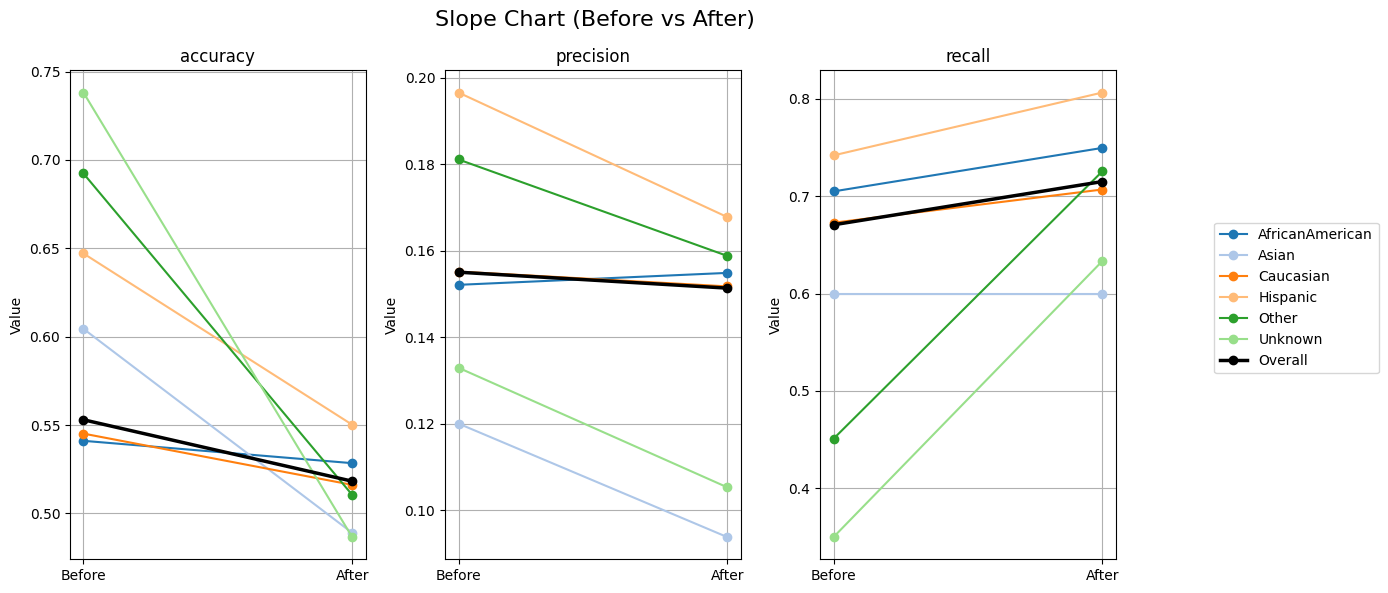

In [44]:
plot_slope_chart(comp_df, metrics_to_plot=["precision", "recall", "accuracy"])

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap



def plot_delta_heatmap(df_comparison, metrics_to_plot=None, figsize=(12, 6)):
    """
    Plot heatmap of metric improvements (delta) per group.

    Only plots rows with level == 'Group' (excludes Overall).

    Parameters:
    - df_comparison: DataFrame with columns ['level', 'group', 'metric', 'before', 'after', 'delta']
    - cmap: color map for heatmap (default 'RdYlGn' where green = improvement)
    - center: center value for heatmap coloring (default 0)
    - figsize: tuple for figure size (default (12, 6))
    """
    # df = df_comparison[df_comparison['level'] == 'Group'].copy()
    df = df_comparison.copy()

    if metrics_to_plot:
        df = df[df['metric'].isin(metrics_to_plot)]
        
    # Separate group and overall
    df_group = df[df['level'] == 'Group']
    df_overall = df[df['level'] == 'Overall']

    # Pivot groups
    pivot_group = df_group.pivot(index="group", columns="metric", values="delta")

    # Pivot overall and rename index to "Overall"
    pivot_overall = df_overall.pivot(index="level", columns="metric", values="delta")
    pivot_overall.index = ['Overall']

    # Combine groups + overall (Overall at bottom)
    combined = pd.concat([pivot_group, pivot_overall])
    
    custom_rwg = LinearSegmentedColormap.from_list(
    "custom_rwg",
    [(0, "red"), (0.5, "white"), (1, "green")]
    )

    plt.figure(figsize=figsize)
    sns.heatmap(combined, annot=True, fmt=".3f", center=0, cmap=custom_rwg,
                linewidths=0.5, linecolor='gray')
    plt.title("Metric Improvement (After - Before) by Group and Overall")
    plt.ylabel("Group / Overall")
    plt.xlabel("Metric")
    plt.tight_layout()
    plt.show()


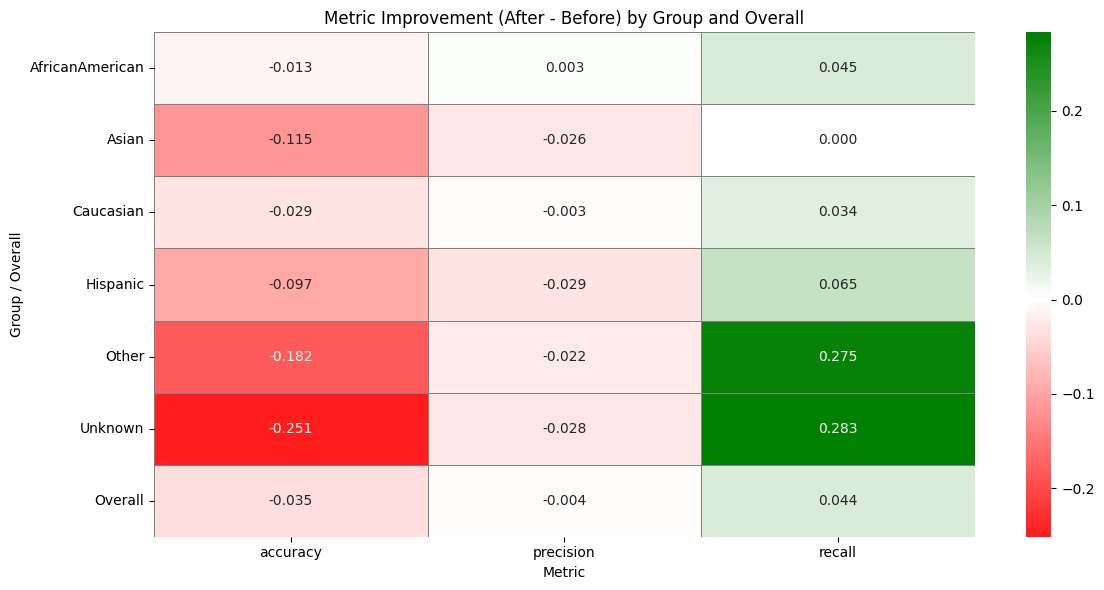

In [46]:
plot_delta_heatmap(comp_df,metrics_to_plot=["precision", "recall", "accuracy"])

## Match Constrain & Metrics

In [47]:
eval_before = evaluate_fairness_metrics(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # ใส่ cat เข้าไป (แบบไม่ one-hot)
    model = model_rf ,
    metrics=None,
    threshold = 0.1,
)

function: evaluate_fairness_metrics is starting...
function: evaluate_fairness_metrics successfully executed at 3.157832145690918s


In [48]:
eval_before

{'race': {'overall': {'accuracy': 0.48277104487389455,
   'precision': 0.14805327868852458,
   'recall': 0.7594160583941606,
   'false positive rate': 0.55218594355285,
   'false negative rate': 0.24058394160583943,
   'true positive rate': 0.7594160583941606,
   'true negative rate': 0.44781405644715,
   'selection rate': 0.5754339993449067,
   'count': 30530.0},
  'by_group':                  accuracy  precision    recall  false positive rate  \
  race                                                                  
  AfricanAmerican  0.500347   0.151159  0.779904             0.533722   
  Asian            0.565934   0.119048  0.666667             0.443114   
  Caucasian        0.471634   0.147024  0.757088             0.565091   
  Hispanic         0.584775   0.184397  0.838710             0.445736   
  Other            0.545455   0.166667  0.705882             0.476190   
  Unknown          0.561012   0.122186  0.633333             0.446078   
  
                   false negative 

### 1. Demographic Parity (ความเท่าเทียมทางประชากร)

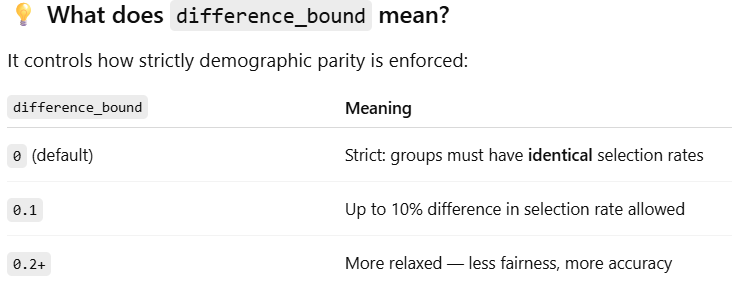

In [49]:
eval_after_dp = mitigate_fairness_disparity(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # e.g., df[['race', 'gender']]
    model = model_rf ,
    constraint=DemographicParity(difference_bound=0.1),
    objective=ErrorRate(costs={"fp": 0.1, "fn": 0.9}), # favor recall first then balance with precision
    metrics = None,
    test_size= 0.3,
)

function: mitigate_fairness_disparity is starting...
function: mitigate_fairness_disparity successfully executed at 63.001598596572876s


In [50]:
eval_after_dp

{'race': {'overall': {'accuracy': 0.5031116934163118,
   'precision': 0.15067515317351735,
   'recall': 0.7395620437956204,
   'false positive rate': 0.5267662792842649,
   'false negative rate': 0.26043795620437954,
   'true positive rate': 0.7395620437956204,
   'true negative rate': 0.4732337207157351,
   'selection rate': 0.5506387160170324,
   'count': 30530.0},
  'by_group':                  accuracy  precision    recall  false positive rate  \
  race                                                                  
  AfricanAmerican  0.522696   0.154096  0.755981             0.505734   
  Asian            0.521978   0.108696  0.666667             0.491018   
  Caucasian        0.492248   0.149510  0.736782             0.539212   
  Hispanic         0.608997   0.191729  0.822581             0.416667   
  Other            0.568765   0.174757  0.705882             0.449735   
  Unknown          0.566964   0.126214  0.650000             0.441176   
  
                   false negati

In [51]:
count_pred_true_by_group(results_dict=eval_after_dp, group_col='race')

,Predicted Negative (0),Predicted Positive (1),Actual Negative (0),Actual Positive (1)
group,,,,
AfricanAmerican,2696,3076,5145,627
Asian,90,92,167,15
Caucasian,10035,12862,20287,2610
Hispanic,312,266,516,62
Other,223,206,378,51
Unknown,363,309,612,60


In [52]:
comp_df = compare_fairness_results_all_metrics(eval_before, eval_after_dp,protected_attr="race")
comp_df.loc[comp_df['metric']=='selection rate']

,level,group,metric,before,after,delta
42,Group,AfricanAmerican,selection rate,0.560464,0.532918,-0.027547
43,Group,Asian,selection rate,0.461538,0.505495,0.043956
44,Group,Caucasian,selection rate,0.586976,0.561733,-0.025243
45,Group,Hispanic,selection rate,0.487889,0.460208,-0.027682
46,Group,Other,selection rate,0.503497,0.480186,-0.023310
47,Group,Unknown,selection rate,0.462798,0.459821,-0.002976
61,Overall,Overall,selection rate,0.575434,0.550639,-0.024795


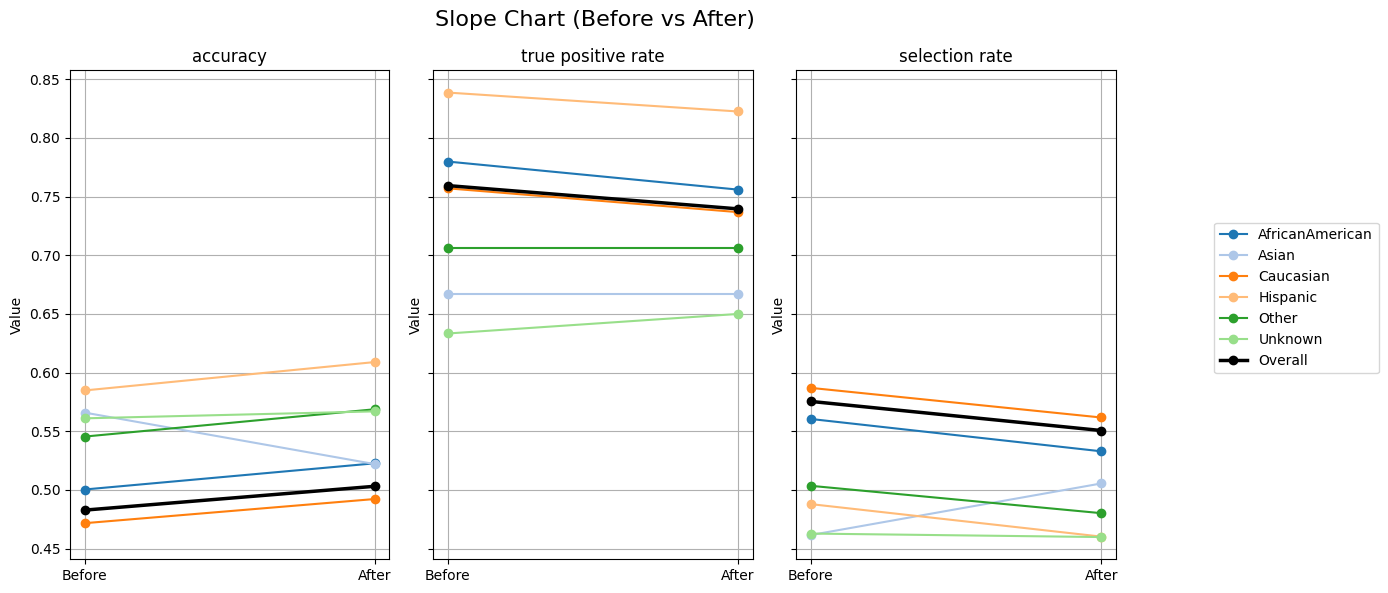

In [53]:
plot_slope_chart(comp_df, metrics_to_plot=["accuracy",'selection rate','true positive rate'],
                sharey=True)

### 2. Equal Opportunity (True Positive Rate Parity)

In [54]:
eval_after_tpr = mitigate_fairness_disparity(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # e.g., df[['race', 'gender']]
    model = model_rf,
    constraint=TruePositiveRateParity(difference_bound=0.1),
    objective=ErrorRate(costs={"fp": 0.1, "fn": 0.9}), # favor recall
    metrics = None,
    test_size= 0.3,
)

function: mitigate_fairness_disparity is starting...
function: mitigate_fairness_disparity successfully executed at 87.86105608940125s


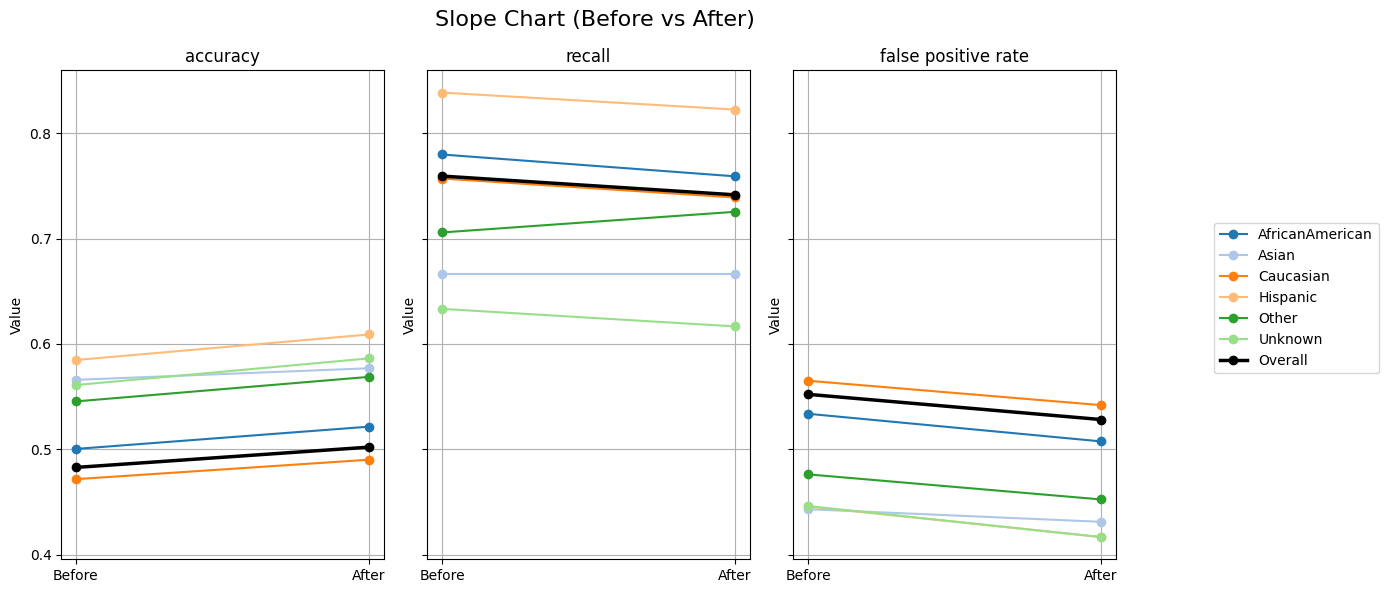

In [55]:
comp_df = compare_fairness_results_all_metrics(eval_before, eval_after_tpr,protected_attr="race")
plot_slope_chart(comp_df, metrics_to_plot=["accuracy",'recall','false positive rate'],sharey=True) 

### 3. False Positive Rate Parity 

In [56]:
eval_after_fpr = mitigate_fairness_disparity(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # e.g., df[['race', 'gender']]
    model = model_rf,
    constraint=FalsePositiveRateParity(difference_bound=0.1),
    objective=ErrorRate(costs={"fp": 0.1, "fn": 0.9}), # favor recall
    metrics = None,
    test_size= 0.3,
)

function: mitigate_fairness_disparity is starting...
function: mitigate_fairness_disparity successfully executed at 70.45361495018005s


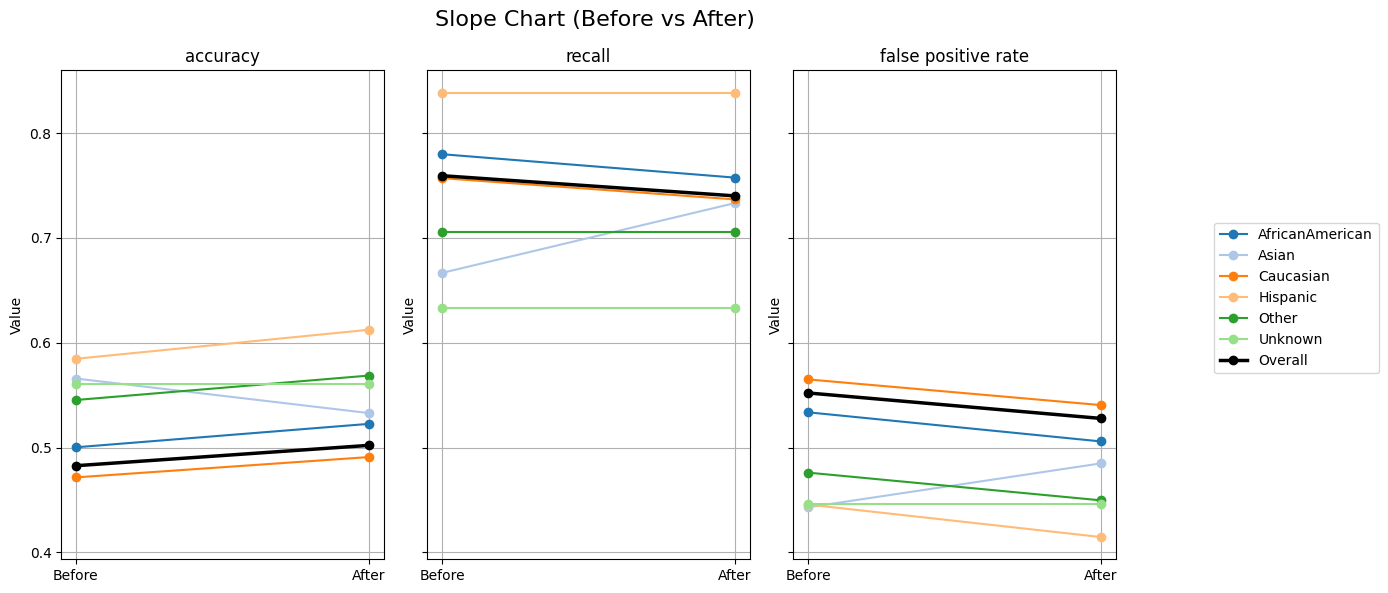

In [57]:
comp_df = compare_fairness_results_all_metrics(eval_before, eval_after_fpr,protected_attr="race")
plot_slope_chart(comp_df, metrics_to_plot=["accuracy",'recall','false positive rate'],sharey=True) 

### 4. Equalized Odds (โอกาสถูก-ผิดเท่ากันทุกกลุ่ม)

In [58]:
eval_after_eo = mitigate_fairness_disparity(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # e.g., df[['race', 'gender']]
    model = model_rf,
    constraint=EqualizedOdds(difference_bound=0.1),
    objective=ErrorRate(costs={"fp": 0.1, "fn": 0.9}), # favor recall ไม่อยากให้หลุด
    metrics = None,
    test_size= 0.3,
)

function: mitigate_fairness_disparity is starting...
function: mitigate_fairness_disparity successfully executed at 82.52485513687134s


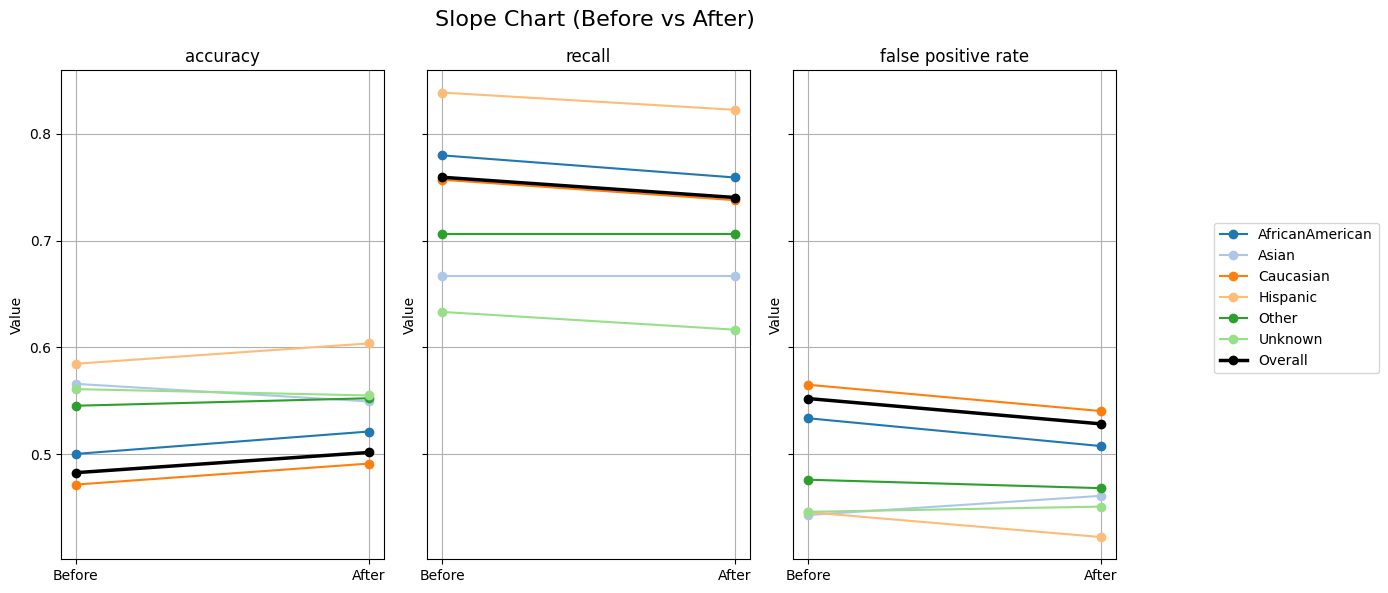

In [59]:
comp_df = compare_fairness_results_all_metrics(eval_before, eval_after_eo,protected_attr="race")
plot_slope_chart(comp_df, metrics_to_plot=["accuracy",'recall','false positive rate'],sharey=True) 

### 5. Error Rate Parity (Equal Error Rates)

In [60]:
eval_after_er = mitigate_fairness_disparity(
    X_ohe=X_ohe,
    y=y,
    X_protected=X_protected,  # e.g., df[['race', 'gender']]
    model = model_rf,
    constraint=ErrorRateParity(difference_bound=0.1),
    objective=ErrorRate(costs={"fp": 0.1, "fn": 0.9}), 
    metrics = None,
    test_size= 0.3,
)

function: mitigate_fairness_disparity is starting...
function: mitigate_fairness_disparity successfully executed at 75.49053978919983s


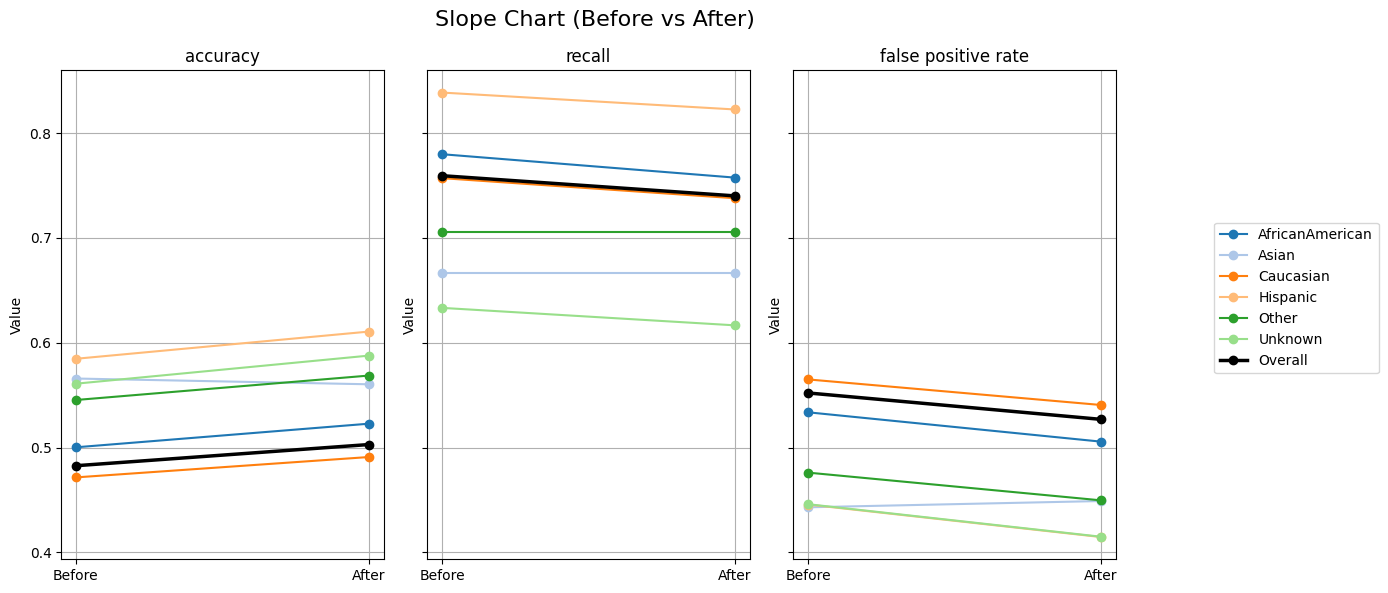

In [61]:
comp_df = compare_fairness_results_all_metrics(eval_before, eval_after_er,protected_attr="race")
plot_slope_chart(comp_df, metrics_to_plot=["accuracy",'recall','false positive rate'],sharey=True) 

[to do]

https://fairlearn.org/v0.12/auto_examples/plot_plotting_metrics_with_error.html#sphx-glr-auto-examples-plot-plotting-metrics-with-error-py

# [to do] ThresholdOptimizer

https://fairlearn.org/v0.12/auto_examples/plot_mitigation_pipeline.html#sphx-glr-auto-examples-plot-mitigation-pipeline-py

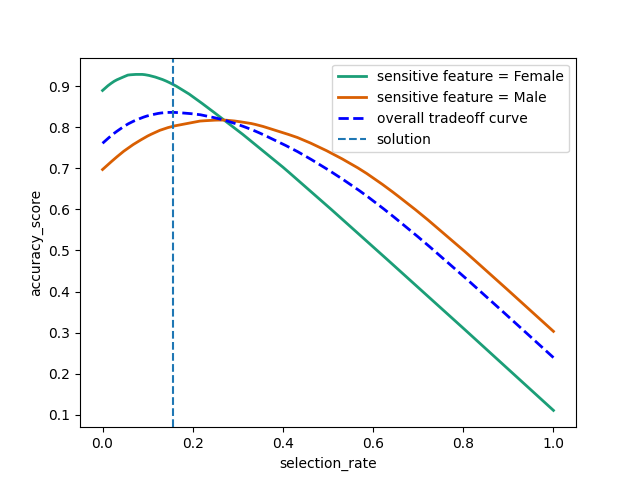

✅ When to Use ThresholdOptimizer?
Use it when:

You already have a trained model (e.g., Logistic Regression, Random Forest)

You want to adjust decision thresholds per group to meet fairness constraints like equalized odds

You don’t want or can’t retrain the model with a fairness constraint

In [28]:
from fairlearn.postprocessing import ThresholdOptimizer, plot_threshold_optimizer
from fairlearn.metrics import MetricFrame
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
import pandas as pd
import matplotlib.pyplot as plt


def mitigate_fairness_disparity_postprocessing(
    X_ohe: pd.DataFrame,
    y: pd.Series,
    X_protected,  # Can be DataFrame or list
    model: BaseEstimator = None,
    constraint: str = "equalized_odds",
    objective: str = "accuracy_score",
    metrics: dict = None,
    test_size: float = 0.3,
    random_state: int = 42,
    return_frame: bool = True,
):
    """
    Mitigate disparity using ThresholdOptimizer (post-processing method).

    Parameters:
    - X_ohe (pd.DataFrame): Feature matrix.
    - y (pd.Series): Binary target.
    - X_protected (Union[pd.DataFrame, list]): Protected attributes (columns or names).
    - model (BaseEstimator): Base classifier. If None, uses LogisticRegression.
    - constraint (str): Fairness constraint to enforce (e.g., 'equalized_odds').
    - objective (str): Objective metric to optimize (e.g., 'accuracy_score').
    - metrics (dict): Dictionary of metrics for evaluation.
    - test_size (float): Test split ratio.
    - random_state (int): Random seed.
    - return_frame (bool): Whether to return full MetricFrame.

    Returns:
    - Dict with results for each protected attribute.
    """

    if isinstance(X_protected, list):
        X_protected = X_ohe[X_protected]

    if model is None:
        model = LogisticRegression(max_iter=1000, solver="liblinear")

    for protected_col in X_protected.columns:
        A = X_protected[protected_col]

        X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
            X_ohe, y, A, test_size=test_size, random_state=random_state
        )

        # Train original model
        model.fit(X_train, y_train)

        # Postprocessing fairness mitigation
        postproc = ThresholdOptimizer(
            estimator=model,
            constraints=constraint,
            objective=objective,
            predict_method="predict_proba"
        )
        postproc.fit(X_train, y_train, sensitive_features=A_train)
        plot_threshold_optimizer(postproc,
                                # x_axis_metric="accuracy", # ใช้ไม่ได้จนกว่าจะอัพเป็น fairlearn v.13
                                # y_axis_metric="selection_rate"
                                )
        
        return postproc


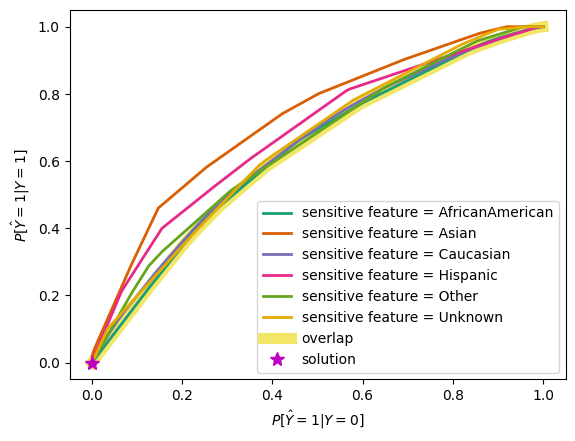

,estimator,LogisticRegre...r='liblinear')
,constraints,'equalized_odds'
,objective,'accuracy_score'
,grid_size,1000
,flip,False
,prefit,False
,predict_method,'predict_proba'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [29]:
mitigate_fairness_disparity_postprocessing(
    X_ohe = X_ohe,
    y = y,
    X_protected = X_protected,
    model = None,
    constraint = "equalized_odds",
    objective= "accuracy_score",
)

https://fairlearn.org/v0.12/auto_examples/plot_credit_loan_decisions.html#sphx-glr-auto-examples-plot-credit-loan-decisions-py

# Proxy Variable

## Identify Proxy Variable

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_proxy_correlation(X_ohe: pd.DataFrame,
                           protected_class: str,
                           top_n: int = 20):
    """
    Plot correlation of all features with the specified protected attribute.

    Parameters:
    - X_ohe: One-hot encoded DataFrame of features (including protected_class)
    - protected_class: The column name of the protected attribute to test against
    - top_n: Number of top correlated features to display

    Output:
    - Barplot showing absolute correlations with the protected attribute
    """
    
    if protected_class not in X_ohe.columns:
        raise ValueError(f"'{protected_class}' not found in DataFrame.")
    
    # Compute correlations
    corr_series = X_ohe.corr()[protected_class].drop(protected_class)
    corr_df = pd.DataFrame({
        "feature": corr_series.index,
        "correlation": corr_series.values,
        "abs_correlation": corr_series.abs().values
    })

    # Sort by absolute correlation
    corr_df = corr_df.sort_values("abs_correlation", ascending=False).head(top_n)

    # Plot using hue workaround to avoid FutureWarning
    corr_df["hue"] = corr_df["feature"]  # dummy hue
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=corr_df,
        y="feature",
        x="correlation",
        hue="hue",              # this suppresses the warning
        palette="coolwarm",
        orient="h",
        dodge=False,
        legend=False            # hide dummy legend
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"Top {top_n} Correlations with '{protected_class}' (Proxy Variable Detection)")
    plt.xlabel("Correlation")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

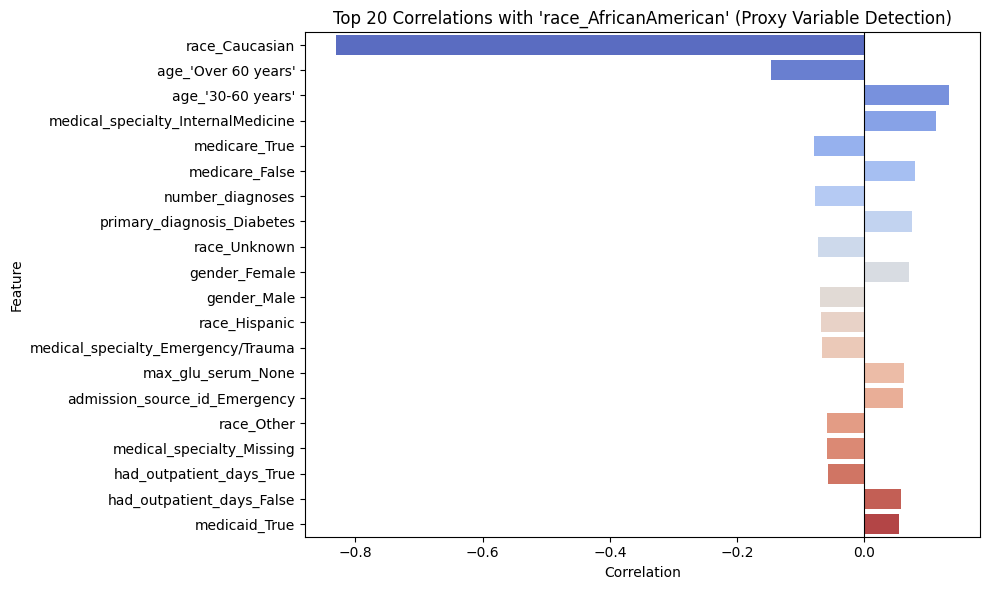

In [120]:
plot_proxy_correlation(X_ohe = X_ohe,
                        protected_class = 'race_AfricanAmerican',
                        top_n= 20)

# มันจะปนๆนิดนึงเพราะเอาดาต้าหลังทำ one-hot เข้า

## Correlation Remover

https://fairlearn.org/v0.12/auto_examples/plot_correlationremover_before_after.html#sphx-glr-auto-examples-plot-correlationremover-before-after-py

- A proxy variable is a feature that is not a protected attribute, but is highly correlated with it.
- Example: zipcode might be highly correlated with race, even if you exclude race from your model.
- These proxy variables can cause indirect discrimination, so we sometimes need to remove or decorrelate them.

In [70]:
X_ohe.loc[:,['race_AfricanAmerican','time_in_hospital','had_inpatient_days_True','medicare_True']] # ไม่เอาพวก _False เพราะมันรู้จาก _True แล้ว

,race_AfricanAmerican,time_in_hospital,had_inpatient_days_True,medicare_True
0,False,1,False,False
1,False,3,False,False
2,True,2,True,False
3,False,2,False,False
4,False,1,False,False
...,...,...,...,...
101761,True,3,False,True
101762,True,5,True,True
101763,False,1,False,True
101764,False,10,True,True


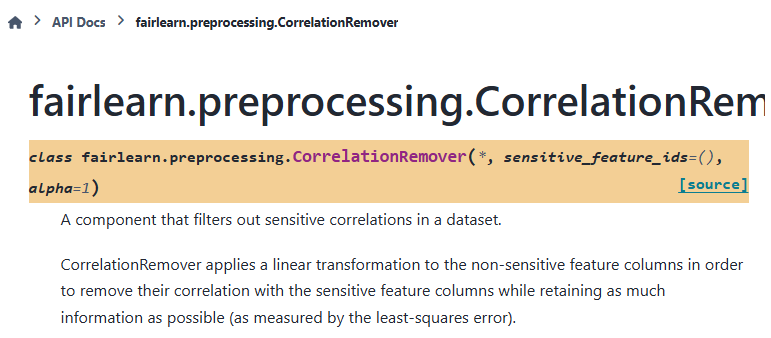
<br>
https://fairlearn.org/v0.12/auto_examples/plot_correlationremover_before_after.html#sphx-glr-auto-examples-plot-correlationremover-before-after-py

In [101]:
from fairlearn.preprocessing import CorrelationRemover

def correlation_remover(
    X_ohe_subset: pd.DataFrame,
    protected_class: str,
    alpha:float=0.5    

):

    '''
    We are now going to fit the CorrelationRemover to the data, and transform it. 
    The transformed array will be placed back in a Pandas DataFrame, for plotting purposes.

    parameter alpha controls how strongly the correlation between features and the sensitive attribute is reduced.
    '''
    
    cr = CorrelationRemover(sensitive_feature_ids=[protected_class])
    X_cr = cr.fit_transform(X_ohe_subset)
    X_cr = pd.DataFrame(X_cr, columns=[col for col in X_ohe_subset.columns if col != protected_class])
    X_cr[protected_class] = X_ohe_subset[protected_class]
    
    cr_alpha = CorrelationRemover(sensitive_feature_ids=[protected_class], alpha=alpha)
    X_cr_alpha = cr_alpha.fit_transform(X_ohe_subset)
    X_cr_alpha = pd.DataFrame(
        X_cr_alpha, columns=[col for col in X_ohe_subset.columns if col != protected_class]
    )
    X_cr_alpha[protected_class] = X_ohe_subset[protected_class]
    
    return X_cr,X_cr_alpha

In [105]:
X_cr,X_cr_alpha = correlation_remover(X_ohe_subset = X_ohe.loc[:,['race_AfricanAmerican','time_in_hospital','had_inpatient_days_True','medicare_True']] ,
                   protected_class = 'race_AfricanAmerican',
                   alpha=0.5)

In [113]:
def plot_heatmap_corr_rm(X_ohe_plot:pd.DataFrame,
                         y:pd.Series,
                         title:str):
    df = X_ohe_plot.copy()
    df["target"] = y
    cols = list(df.columns)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(round(df.corr(), 2), cmap="coolwarm")

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(np.arange(len(cols)))
    ax.set_yticklabels(cols)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(
                j,
                i,
                round(df.corr().to_numpy()[i, j], 2),
                ha="center",
                va="center",
            )

    ax.set_title(f"{title}")
    plt.show()

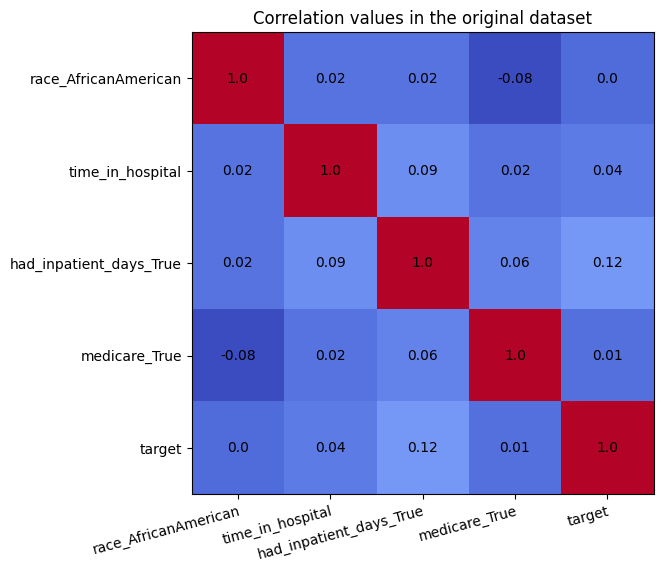

In [114]:
plot_heatmap_corr_rm(X_ohe.loc[:,['race_AfricanAmerican','time_in_hospital','had_inpatient_days_True','medicare_True']] ,
                     y =y,
                     title="Correlation values in the original dataset")

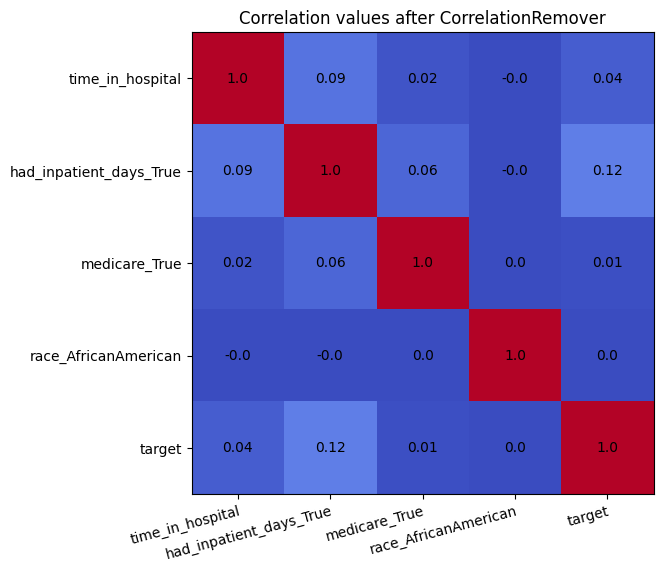

In [109]:
plot_heatmap_corr_rm(X_cr, 
                     y=y,
                     title="Correlation values after CorrelationRemover")

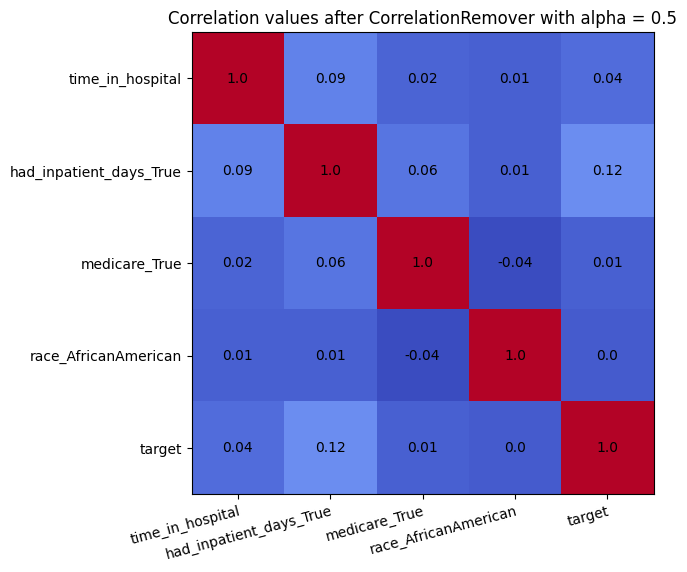

In [110]:
plot_heatmap_corr_rm(X_cr_alpha, 
                     y=y,
                     title="Correlation values after CorrelationRemover with alpha = 0.5")